# How are the peak areas calculated?

This walkthrough illustrates the peak detection, outlier removal, and the peak-area (AUC) calculation of the 3B-QIRT-ELISA Peak Analyzer
on one raw scan, scan 11 of fed-state Rat 1, one step at a time. It then repeats the calculation
for all 24 scans.

Each step is written out in full and checked against `pipeline.py`, the app's processing chain as
plain functions. The last section shows that the notebook reproduces the app's exported results for all 24 scans,
`data/processed/Fed_state_Rat1_app_output.csv`.

| Channel | Hormone | Savitzky–Golay (window, order) | Peak prominence (pA) | Preamplifier gain (pA/V) | Minimum peak separation (samples) | Fold threshold | Prominence evaluation window (samples) |
|---|---|---|---|---|---|---|---|
| QD565 | C-peptide | (40, 1) | 0.05 | 100 | 50 | 20 | 350 |
| QD605 | Glucagon | (10, 1) | 0.5 | 100 | 50 | 20 | 350 |
| QD655 | Insulin | (20, 1) | 0.25 | 100 | 50 | 20 | 350 |

These are the settings used for every scan in the manuscript.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter

REPO = Path.cwd().resolve().parent
sys.path.insert(0, str(REPO / "analysis"))
import pipeline                             # the app's processing chain as plain functions

RAW = REPO / "data/raw/fed_state_Rat1_raw_scans"
EXPORT = REPO / "data/processed/Fed_state_Rat1_app_output.csv"

FOLD, N_MIN = 20.0, 50                      # fold threshold Λ, minimum peak separation (samples)
CHANNELS = {  # app column: hormone, colour, Savitzky-Golay (window, order), prominence (pA), column prefix in EXPORT
    "Signal565": ("C-peptide", "#408002", (40, 1), 0.05, "QD565"),
    "Signal605": ("Glucagon",  "#E59906", (10, 1), 0.50, "QD605"),
    "Signal655": ("Insulin",   "#9C271F", (20, 1), 0.25, "QD655"),
}
GREY, INK, SLATE = "#9CA3AF", "#1F2937", "#64748B"

export = pd.read_csv(EXPORT)                # the app's "Download wide format CSV", one row per scan
export.index = export["File"].str.extract(r"(\d+)", expand=False).astype(int)
def exported(scan, qd):
    # the app's peak area for one scan and hormone. NaN where the app found no peaks
    e = export.loc[scan]
    return e[f"{qd}_Avg_AUC"] if e[f"{qd}_Peaks"] > 0 else np.nan

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 9, "axes.titlesize": 10, "axes.labelsize": 9,
    "font.family": "sans-serif", "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": GREY,
    "axes.labelcolor": "#374151", "axes.titlecolor": INK, "xtick.color": "#6B7280", "ytick.color": "#6B7280",
    "axes.grid": True, "grid.color": "#E5E7EB", "grid.linewidth": 0.6, "axes.axisbelow": True,
    "legend.frameon": False, "legend.fontsize": 8.5, "mathtext.default": "regular",
})

## 1. Load and scale

Each scan is a CSV file exported by Digilent WaveForms software: a 16-line preamble (device, acquisition
time, sample rate, channel settings), then one row per sample with the time and four channel
voltages. Channel 1 is QDot 655 (insulin), channel 2 QDot 605 (glucagon), channel 3 is a high-pass filter that gets all QDots and
channel 4 QDot 565 (C-peptide).

In [2]:
SCAN, CH = 11, "Signal655"                  # walk through scan 11, insulin channel
HORMONE, COLOUR, (WINDOW, ORDER), P_PROM, QD = CHANNELS[CH]
path = RAW / f"scan{SCAN}.csv"

with open(path) as f:
    print("".join(next(f) for _ in range(18)))    # preamble plus the first data rows

#Digilent WaveForms Oscilloscope Acquisition,,,,
#Device Name: Discovery3,,,,
#Serial Number: SN:210415BB0163,,,,
#Device Plus: Discovery3,,,,
#Serial Plus: SN:210415BB0594,,,,
#Date Time: 2025-03-28 15:31:10.863.346.700,,,,
#Sample rate: 215.579Hz,,,,
#Samples: 14809,,,,
#Trigger: Source: Channel 1 Type: Edge Condition: Rising Level: 0 V Hyst.: Auto HoldOff: 0 s,,,,
#Channel 1: Range: 500 mV/div Offset: -1.5 V Sample Mode: Average,,,,
#Channel 2: Range: 500 mV/div Offset: -2.25 V Sample Mode: Average,,,,
#Channel 3: Range: 1 V/div Offset: 1 V Sample Mode: Average,,,,
#Channel 4: Range: 200 mV/div Offset: -820 mV Sample Mode: Average,,,,
,,,,
#,,,,
#Time (s),Channel 1 (V),Channel 2 (V),Channel 3 (V),Channel 4 (V)
40.97338461,1.426714561,2.230656593,-0.93112139,0.786032086
40.97802328,0.236694013,1.919110363,0.55612885,0.040561079



`pipeline.load_scan` drops the preamble and the first 15 samples, and then multiplies every channel by
its preamplifier gain (100) to give the photocurrent in pA.

In [3]:
df = pipeline.load_scan(path)
t = df["time"].to_numpy() - df["time"].iloc[0]   # time within the scan (s)
raw = df[CH].to_numpy()
print(f"{len(df)} samples over {t[-1]:.1f} s")
df.head()

14794 samples over 68.6 s


,time,Signal655,Signal605,SignalAllQDots,Signal565
0,41.042965,23.297798,190.487195,53.720021,3.741464
1,41.047603,23.774420,190.802705,53.810157,4.339288
2,41.052242,23.111996,190.640905,49.123066,3.843723
3,41.056881,22.934272,190.422475,51.376475,3.576275
4,41.061519,23.540148,190.600455,55.793158,4.008911


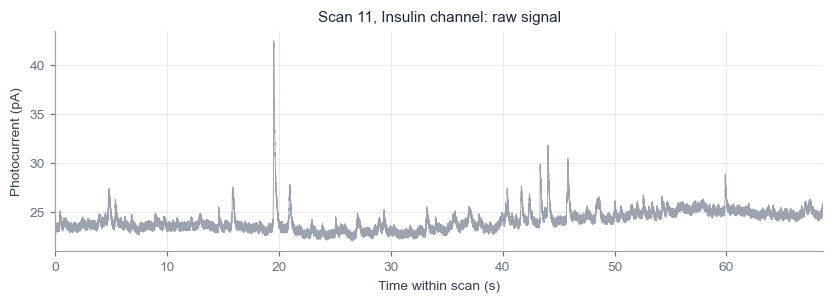

In [4]:
fig, ax = plt.subplots(figsize=(9, 2.6))
ax.plot(t, raw, color=GREY, lw=0.6)
ax.set(xlabel="Time within scan (s)", ylabel="Photocurrent (pA)", xlim=(0, t[-1]),
       title=f"Scan {SCAN}, {HORMONE} channel: raw signal")
plt.show()

## 2. Smooth

A Savitzky–Golay filter fits a straight line (order 1) to a sliding window of samples. The app always applies this non-aggressive filter. The filter's window
and order can be changed on the Processing tab in case an aggressive smoothing filter is required (when, experimentally, the blood flows more into the optic device).

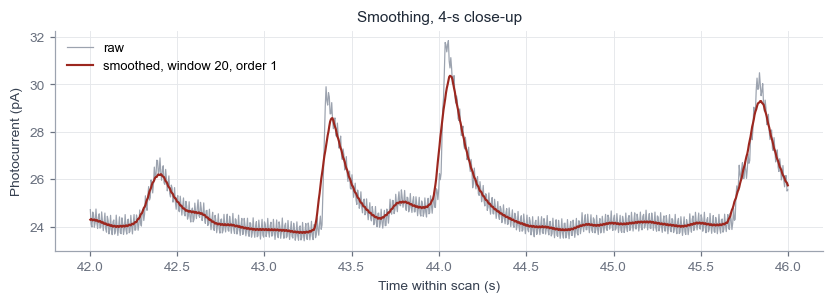

In [5]:
smoothed = savgol_filter(raw, WINDOW, ORDER)

zoom = (t > 42) & (t < 46)
fig, ax = plt.subplots(figsize=(9, 2.6))
ax.plot(t[zoom], raw[zoom], color=GREY, lw=0.8, label="raw")
ax.plot(t[zoom], smoothed[zoom], color=COLOUR, lw=1.4, label=f"smoothed, window {WINDOW}, order {ORDER}")
ax.set(xlabel="Time within scan (s)", ylabel="Photocurrent (pA)", title="Smoothing, 4-s close-up")
ax.legend(loc="upper left")
plt.show()

## 3. Remove the baseline

The slowly drifting background is estimated in three moves:

1. The Fourier transform of the smoothed signal is truncated to its first 100 coefficients, which
   leaves a slowly varying curve. Only the positions of its local minima are used.
2. At those positions the smoothed signal is taken as the background, and the baseline β(t) joins
   these anchor points with straight lines.
3. The corrected signal u\* is the smoothed signal minus the baseline, with negative values clamped to 0.

79 anchor points


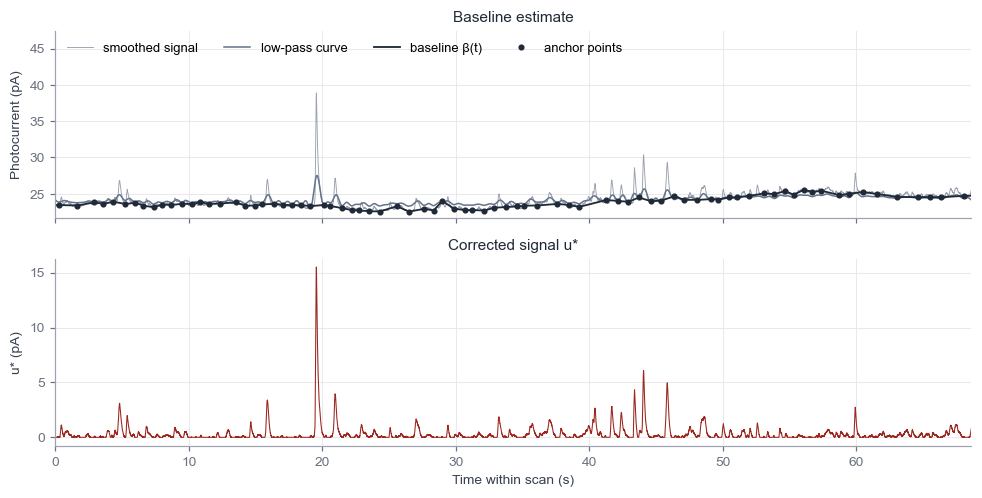

In [6]:
spectrum = np.fft.fft(smoothed)
spectrum[100:] = 0                                   # keep the first 100 coefficients
low_pass = np.real(np.fft.ifft(spectrum))
anchors, _ = find_peaks(-low_pass)                   # local minima of the low-pass curve
baseline = np.interp(t, t[anchors], smoothed[anchors])
corrected = np.maximum(smoothed - baseline, 0)

assert np.allclose(corrected, pipeline.baseline_correct(smoothed, t)[0])
print(f"{len(anchors)} anchor points")

fig, (a1, a2) = plt.subplots(2, 1, figsize=(9, 4.6), sharex=True)
a1.plot(t, smoothed, color=GREY, lw=0.6, label="smoothed signal")
a1.plot(t, low_pass, color=SLATE, lw=1.0, label="low-pass curve")
a1.plot(t, baseline, color=INK, lw=1.2, label="baseline β(t)")
a1.plot(t[anchors], smoothed[anchors], "o", ms=3, color=INK, label="anchor points")
a1.set(ylabel="Photocurrent (pA)", title="Baseline estimate", ylim=(None, smoothed.max() * 1.22))
a1.legend(loc="upper left", ncol=4)
a2.plot(t, corrected, color=COLOUR, lw=0.7)
a2.set(xlabel="Time within scan (s)", ylabel="u* (pA)", xlim=(0, t[-1]), title="Corrected signal u*")
plt.tight_layout()
plt.show()

## 4. Screen out outlier peaks (adaptive Hampel)

Candidate peaks are local maxima of u\* that stand out by at least the prominence (0.25 pA for
insulin), lie at least 50 samples apart and exceed a small minimum height. `h_med` is the median
candidate height. A candidate is flagged as an outlier, such as an air bubble or multiple beads,
when it is more than Λ = 20 times taller than `h_med`.

This fold-change rule is the classical one-sided Hampel test, height − `h_med` > `k_eff` × MAD,
with its multiplier `k_eff` = (Λ − 1) / RSD set by the spread of the candidates themselves
(RSD = MAD / `h_med`, MAD = median absolute deviation of the heights).

72 candidate peaks, median height h_med = 0.723 pA
MAD = 0.358 pA,  RSD = 0.495,  k_eff = 38.4
Hampel threshold h_med + k_eff × MAD = 14.47 pA = Λ × h_med = 14.47 pA
flagged as outliers: 1, height [15.52] pA


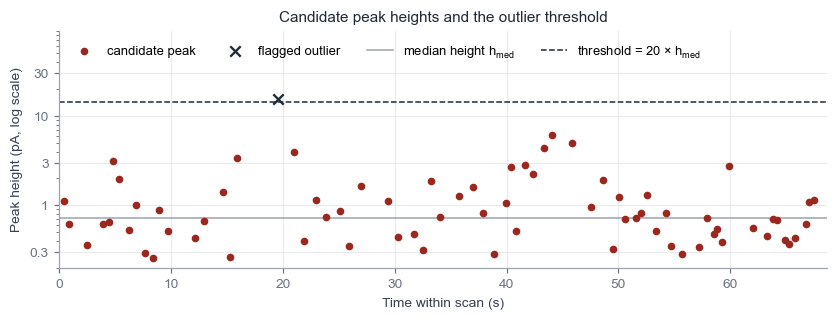

In [7]:
min_height = max(np.median(corrected) + 0.1 * np.std(corrected), P_PROM)
candidates, _ = find_peaks(corrected, height=min_height, prominence=P_PROM, distance=N_MIN)
h = corrected[candidates]

h_med = np.median(h)
mad = np.median(np.abs(h - h_med))
rsd = mad / h_med
k_eff = (FOLD - 1) / rsd
is_outlier = h > FOLD * h_med

print(f"{len(candidates)} candidate peaks, median height h_med = {h_med:.3f} pA")
print(f"MAD = {mad:.3f} pA,  RSD = {rsd:.3f},  k_eff = {k_eff:.1f}")
print(f"Hampel threshold h_med + k_eff × MAD = {h_med + k_eff * mad:.2f} pA = Λ × h_med = {FOLD * h_med:.2f} pA")
print(f"flagged as outliers: {is_outlier.sum()}, height {h[is_outlier].round(2)} pA")

outliers_p, repaired_p, retained_p, regions_p, _ = pipeline.adaptive_hampel(corrected, FOLD, P_PROM, N_MIN)
assert list(outliers_p) == list(candidates[is_outlier])

fig, ax = plt.subplots(figsize=(9, 2.8))
ax.scatter(t[candidates[~is_outlier]], h[~is_outlier], s=16, color=COLOUR, label="candidate peak", zorder=3)
ax.scatter(t[candidates[is_outlier]], h[is_outlier], s=46, marker="x", color=INK, lw=1.5,
           label="flagged outlier", zorder=4)
ax.axhline(h_med, color=GREY, lw=1.0, label=r"median height $h_{med}$")
ax.axhline(FOLD * h_med, color=INK, lw=1.0, ls="--", label=rf"threshold = {FOLD:.0f} × $h_{{med}}$")
ax.set_yscale("log")
ax.set_yticks([0.3, 1, 3, 10, 30], ["0.3", "1", "3", "10", "30"])
ax.yaxis.set_minor_formatter(plt.NullFormatter())
ax.set(xlabel="Time within scan (s)", ylabel="Peak height (pA, log scale)", xlim=(0, t[-1]), ylim=(0.2, 90),
       title="Candidate peak heights and the outlier threshold")
ax.legend(loc="upper left", ncol=4)
plt.show()

## 5. Excise outliers

Around each outlier apex, a window of max(10, ⌊5 × height / `h_med`⌋) samples on either side is
replaced by a straight line joining the samples just outside the window, so the spike can
contribute neither a peak nor area.

excised: 19.05–20.04 s (215 samples)


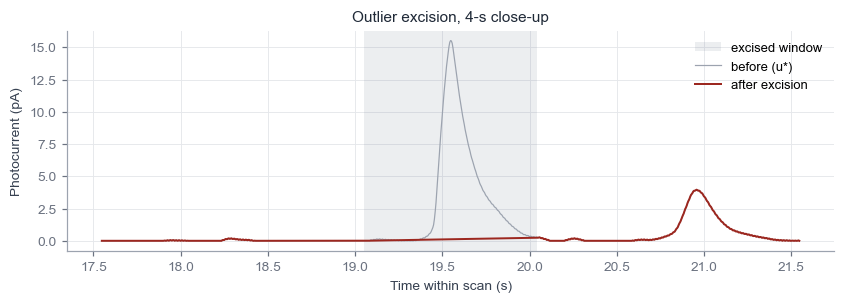

In [8]:
repaired = corrected.copy()
regions = []
for i in candidates[is_outlier]:
    w = max(10, int(corrected[i] / h_med * 5))
    l, r = max(0, i - w), min(len(corrected) - 1, i + w)
    left, right = corrected[max(0, l - 1)], corrected[min(len(corrected) - 1, r + 1)]
    repaired[l:r + 1] = np.linspace(left, right, r - l + 1)
    regions.append((l, r))

assert np.allclose(repaired, repaired_p) and regions == regions_p              # same as the app
print("excised:", ", ".join(f"{t[l]:.2f}–{t[r]:.2f} s ({r - l + 1} samples)" for l, r in regions))

i = candidates[is_outlier][0]
zoom = (t > t[i] - 2) & (t < t[i] + 2)
fig, ax = plt.subplots(figsize=(9, 2.6))
for l, r in regions:
    ax.axvspan(t[l], t[r], color=SLATE, alpha=0.12, lw=0, label="excised window")
ax.plot(t[zoom], corrected[zoom], color=GREY, lw=0.8, label="before (u*)")
ax.plot(t[zoom], repaired[zoom], color=COLOUR, lw=1.3, label="after excision")
ax.set(xlabel="Time within scan (s)", ylabel="Photocurrent (pA)", title="Outlier excision, 4-s close-up")
ax.legend(loc="upper right")
plt.show()

## 6. Find the peaks to integrate

Peak detection runs on the repaired signal, with the same prominence and separation and a
higher minimum height: the median height of the candidates that were not flagged (or the signal's
standard deviation, if larger). Peak bases are searched within a 350-sample window (`wlen`), and
any peak inside an excised window, or within 50 samples of one, is dropped.

minimum height 0.827 pA: 29 peaks found, 29 kept


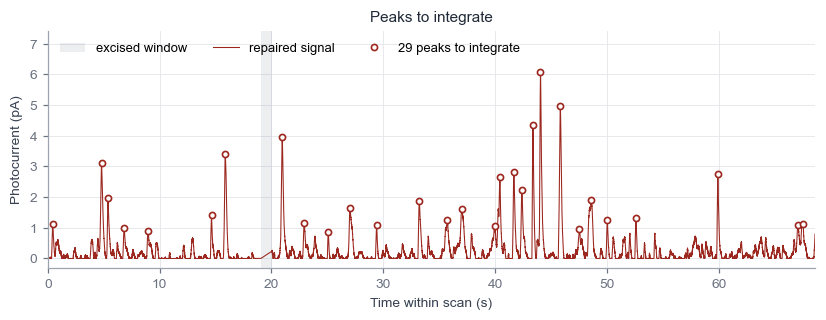

In [9]:
height_2 = max(np.median(h[~is_outlier]), np.std(corrected))
found, props = find_peaks(repaired, height=height_2, prominence=P_PROM, distance=N_MIN, wlen=350)
keep = np.array([not any(l - N_MIN <= p <= r + N_MIN for l, r in regions) for p in found])
peaks = found[keep]
left_bases, right_bases = props["left_bases"][keep], props["right_bases"][keep]

assert list(peaks) == list(pipeline.robust_peak_detection(corrected, t, FOLD, P_PROM, N_MIN)[0])
print(f"minimum height {height_2:.3f} pA: {len(found)} peaks found, {len(peaks)} kept")

fig, ax = plt.subplots(figsize=(9, 2.8))
for l, r in regions:
    ax.axvspan(t[l], t[r], color=SLATE, alpha=0.12, lw=0, label="excised window")
ax.plot(t, repaired, color=COLOUR, lw=0.7, label="repaired signal")
ax.plot(t[peaks], repaired[peaks], "o", ms=4, mfc="white", mec=COLOUR, mew=1.1, label=f"{len(peaks)} peaks to integrate")
ax.set(xlabel="Time within scan (s)", ylabel="Photocurrent (pA)", xlim=(0, t[-1]), ylim=(None, repaired[peaks].max() * 1.22),
       title="Peaks to integrate")
ax.legend(loc="upper left", ncol=3)
plt.show()

## 7. Integrate

Each peak's area A<sub>i</sub> is the trapezoidal integral of the repaired signal between the left
and right bases that `find_peaks` reports for that peak, in pA·s.

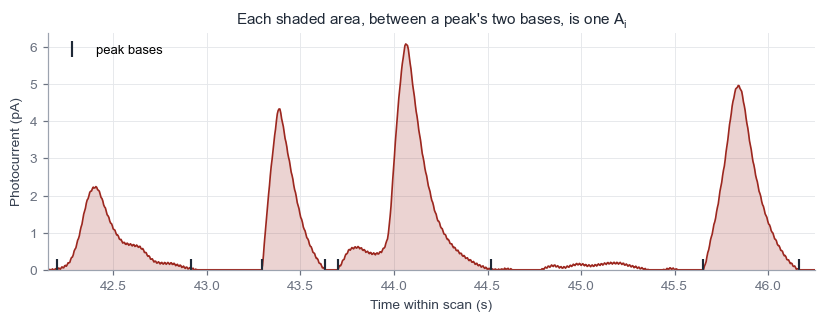

,peak time (s),height (pA),left base (s),right base (s),area A_i (pA·s)
0,0.445,1.123,0.320,1.234,0.367
1,4.810,3.103,4.319,5.219,0.832
2,5.376,1.980,5.251,5.947,0.407
3,6.823,1.003,6.703,7.301,0.224
4,8.957,0.886,8.735,9.435,0.255
5,14.640,1.410,14.538,14.918,0.218
6,15.874,3.401,15.688,16.212,0.721
7,20.958,3.960,20.600,21.482,0.936


In [10]:
areas = np.array([np.trapezoid(repaired[l:r + 1], t[l:r + 1]) for l, r in zip(left_bases, right_bases)])

X0, X1 = 42.15, 46.25
zoom = (t > X0) & (t < X1)
fig, ax = plt.subplots(figsize=(9, 2.8))
ax.plot(t[zoom], repaired[zoom], color=COLOUR, lw=1.1)
for p, l, r in zip(peaks, left_bases, right_bases):
    if X0 < t[l] and t[r] < X1:
        ax.fill_between(t[l:r + 1], 0, repaired[l:r + 1], color=COLOUR, alpha=0.2, lw=0)
        ax.plot([t[l], t[r]], [0, 0], "|", ms=14, mew=1.4, color=INK)
ax.plot([], [], "|", ms=10, mew=1.4, color=INK, label="peak bases")
ax.set(xlabel="Time within scan (s)", ylabel="Photocurrent (pA)", ylim=(0, None), xlim=(X0, X1),
       title=r"Each shaded area, between a peak's two bases, is one $A_i$")
ax.legend(loc="upper left")
plt.show()

pd.DataFrame({"peak time (s)": t[peaks], "height (pA)": repaired[peaks],
              "left base (s)": t[left_bases], "right base (s)": t[right_bases],
              "area A_i (pA·s)": areas}).round(3).head(8)

## 8. Summarize the scan

The scan value Ā is the mean of the areas that lie between their 10th and 90th percentiles, so a
few unusually small or large peaks cannot move it much.

29 peaks, 23 kept after trimming;  Ā = 0.491855 pA·s
pipeline.py: 0.491855   app's export: 0.491855


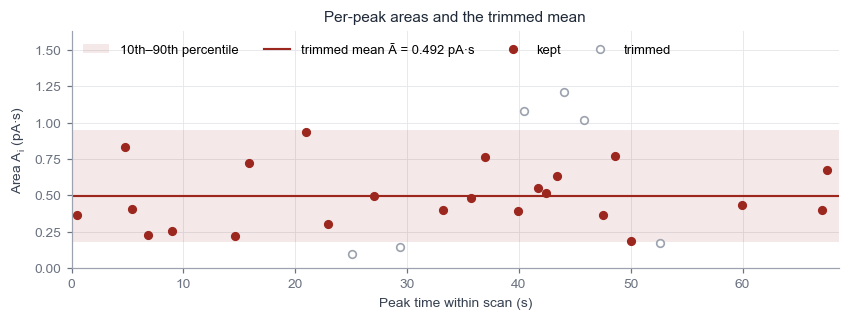

In [11]:
p10, p90 = np.percentile(areas, [10, 90])
kept = (areas >= p10) & (areas <= p90)
A_bar = areas[kept].mean()

check = pipeline.analyze(path, CH, FOLD, P_PROM, N_MIN, (WINDOW, ORDER))["avg_auc"]
print(f"{len(areas)} peaks, {kept.sum()} kept after trimming;  Ā = {A_bar:.6f} pA·s")
print(f"pipeline.py: {check:.6f}   app's export: {exported(SCAN, QD):.6f}")

fig, ax = plt.subplots(figsize=(9, 2.8))
ax.axhspan(p10, p90, color=COLOUR, alpha=0.1, lw=0, label="10th–90th percentile")
ax.axhline(A_bar, color=COLOUR, lw=1.4, label=f"trimmed mean Ā = {A_bar:.3f} pA·s")
ax.plot(t[peaks][kept], areas[kept], "o", ms=5, color=COLOUR, label="kept")
ax.plot(t[peaks][~kept], areas[~kept], "o", ms=5, mfc="white", mec=GREY, mew=1.1, label="trimmed")
ax.set(xlabel="Peak time within scan (s)", ylabel=r"Area $A_i$ (pA·s)", xlim=(0, t[-1]), ylim=(0, areas.max() * 1.35),
       title="Per-peak areas and the trimmed mean")
ax.legend(loc="upper left", ncol=4)
plt.show()

## The same steps for all three hormones

`pipeline.analyze` runs steps 1 to 8 in one call. Here it is applied to all three channels of
scan 11, each with its own smoothing window and prominence.

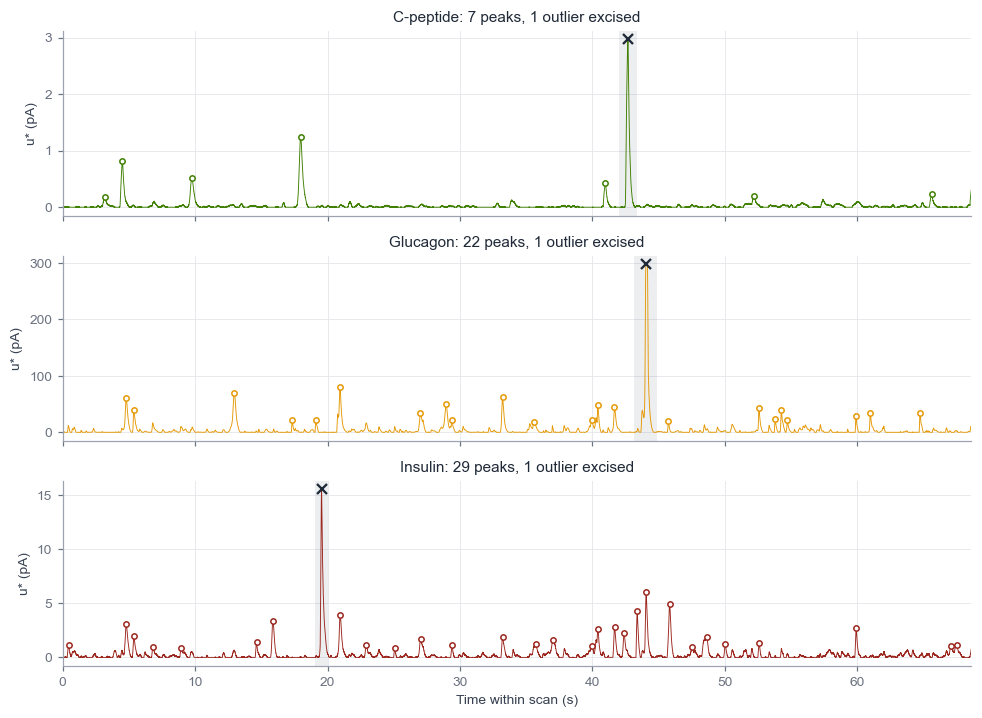

,hormone,peaks,outliers,Ā notebook (pA·s),Ā app export (pA·s)
0,C-peptide,7,1,0.123198,0.123198
1,Glucagon,22,1,7.627598,7.627598
2,Insulin,29,1,0.491855,0.491855


In [12]:
fig, axes = plt.subplots(3, 1, figsize=(9, 6.6), sharex=True)
summary = []
for ax, (ch, (hormone, colour, sg, prom, qd)) in zip(axes, CHANNELS.items()):
    r = pipeline.analyze(path, ch, FOLD, prom, N_MIN, sg)
    tt = r["t"] - r["t"][0]
    for l, rr in r["regions"]:
        ax.axvspan(tt[l], tt[rr], color=SLATE, alpha=0.12, lw=0)
    ax.plot(tt, r["corrected"], color=colour, lw=0.6)
    ax.plot(tt[r["peaks"]], r["clean"][r["peaks"]], "o", ms=3.5, mfc="white", mec=colour, mew=1)
    ax.plot(tt[r["outliers"]], r["corrected"][r["outliers"]], "x", ms=7, color=INK, mew=1.5)
    ax.set(ylabel="u* (pA)", title=f"{hormone}: {len(r['peaks'])} peaks, {len(r['outliers'])} outlier{'s' if len(r['outliers']) != 1 else ''} excised")
    summary.append({"hormone": hormone, "peaks": len(r["peaks"]), "outliers": len(r["outliers"]),
                    "Ā notebook (pA·s)": r["avg_auc"], "Ā app export (pA·s)": exported(SCAN, qd)})
axes[-1].set(xlabel="Time within scan (s)", xlim=(0, tt[-1]))
plt.tight_layout()
plt.show()
pd.DataFrame(summary).round(6)

## All 24 scans

Running the same calculation on every scan and channel reproduces the app's exported peak
areas, peak counts and outlier counts; the cell stops with an error if any of them differs.
Insulin scan 14 has no detectable peaks; the app exports a peak area of 0 for it, which is
treated as missing here.

In [13]:
records = []
for ch, (hormone, colour, sg, prom, qd) in CHANNELS.items():
    for scan in range(1, 25):
        r = pipeline.analyze(RAW / f"scan{scan}.csv", ch, FOLD, prom, N_MIN, sg)
        records.append({"scan": scan, "hormone": hormone,
                        "A_bar": r["avg_auc"] if len(r["peaks"]) else np.nan,
                        "app export": exported(scan, qd),
                        "counts match": (len(r["peaks"]), len(r["outliers"]))
                                        == (export.loc[scan, f"{qd}_Peaks"], export.loc[scan, f"{qd}_Outliers"])})
per_scan = pd.DataFrame(records)

has_value = per_scan["app export"].notna()
matches = np.isclose(per_scan["A_bar"], per_scan["app export"], rtol=1e-9)[has_value]
print(f"{matches.sum()} of {has_value.sum()} peak areas and {per_scan['counts match'].sum()} of {len(per_scan)} "
      "peak and outlier counts match the app's export")
assert matches.all() and per_scan["counts match"].all(), "Some recomputed values differ from the app's export"
per_scan.pivot(index="scan", columns="hormone", values="A_bar")[["C-peptide", "Glucagon", "Insulin"]].round(4)

71 of 71 peak areas and 72 of 72 peak and outlier counts match the app's export


hormone,C-peptide,Glucagon,Insulin
scan,,,
1,0.1845,3.2143,0.2491
2,0.1731,9.4391,0.9756
3,0.1632,7.5324,0.6134
4,0.0545,6.2642,0.3216
5,0.0634,3.8791,0.3241
6,0.3205,4.6350,0.4219
7,0.0836,6.6430,0.4805
8,0.0896,4.8488,0.4228
9,0.0538,4.7165,1.1232


## Normalization and the 2.5-min time course

Each hormone's scan values are divided by their mean over all scans, F<sub>0</sub>, so 1 is the
average level. Consecutive pairs of scans (1 and 2, 3 and 4, …) are then averaged into 12 points,
2.5 min apart, from 0 to 27.5 min. The last two minutes of this recording were missing for rat 1 only, so the
30-min point repeats the 27.5-min values (dotted segment) to build the complete profile.

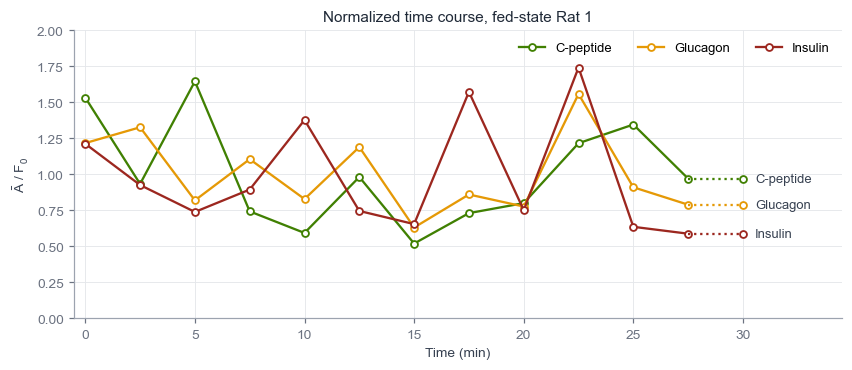

hormone,C-peptide,Glucagon,Insulin
time (min),,,
0.0,1.532,1.216,1.211
2.5,0.932,1.326,0.925
5.0,1.645,0.818,0.738
7.5,0.742,1.104,0.893
10.0,0.592,0.828,1.376
12.5,0.981,1.189,0.745
15.0,0.518,0.630,0.653
17.5,0.730,0.859,1.572
20.0,0.799,0.775,0.751


In [14]:
per_scan["normalized"] = per_scan["A_bar"] / per_scan.groupby("hormone")["A_bar"].transform("mean")
per_scan["time (min)"] = (per_scan["scan"] - 1) // 2 * 2.5
course = per_scan.groupby(["time (min)", "hormone"])["normalized"].mean().unstack()[["C-peptide", "Glucagon", "Insulin"]]
course.loc[30.0] = course.loc[27.5]          # the last two minutes were not saved: 30 min repeats 27.5 min

fig, ax = plt.subplots(figsize=(9, 3.4))
for ch, (hormone, colour, *_ ) in CHANNELS.items():
    y = course[hormone]
    ax.plot(y.index[:-1], y.iloc[:-1], "-o", color=colour, lw=1.5, ms=4.5, mfc="white", mew=1.2, label=hormone)
    ax.plot(y.index[-2:], y.iloc[-2:], ":o", color=colour, lw=1.5, ms=4.5, mfc="white", mew=1.2, markevery=[1])
    ax.annotate(hormone, (y.index[-1], y.iloc[-1]), xytext=(8, 0),
                textcoords="offset points", va="center", fontsize=8.5, color="#374151")
ax.set(xlabel="Time (min)", ylabel=r"$\bar{A}$ / $F_0$", ylim=(0, 2), xlim=(-0.5, 34.5), xticks=range(0, 31, 5),
       title="Normalized time course, fed-state Rat 1")
ax.legend(loc="upper right", ncol=3)
plt.show()
course.round(3)